In [1]:
import torch
from env import FJSPTEnv
import matplotlib.pyplot as plt
from IPython.display import clear_output
import time
from greedy_policies import GreedyPolicy
from rl4co.envs import ENV_REGISTRY

ENV_REGISTRY["fjspt"] = FJSPTEnv

env = FJSPTEnv(
    generator_params={
        "num_jobs": 3,  # the total number of jobs
        "num_machines": 2,  # the total number of machines that can process operations
        "num_trucks": 1,  # the total number of trucks
        "min_ops_per_job": 2,  # minimum number of operatios per job
        "max_ops_per_job": 3,  # maximum number of operations per job
        "min_processing_time": 1,  # the minimum time required for a machine to process an operation
        "max_processing_time": 5,  # the maximum time required for a machine to process an operation
        "min_transportation_time": 1,  # the minimum time required for a truck to transport
        "max_transportation_time": 5,  # the maximum time required for a truck to transport
        "min_eligible_ma_per_op": 1,  # the minimum number of machines capable to process an operation
        "max_eligible_ma_per_op": 2,  # the maximum number of machines capable to process an operation
    },
)

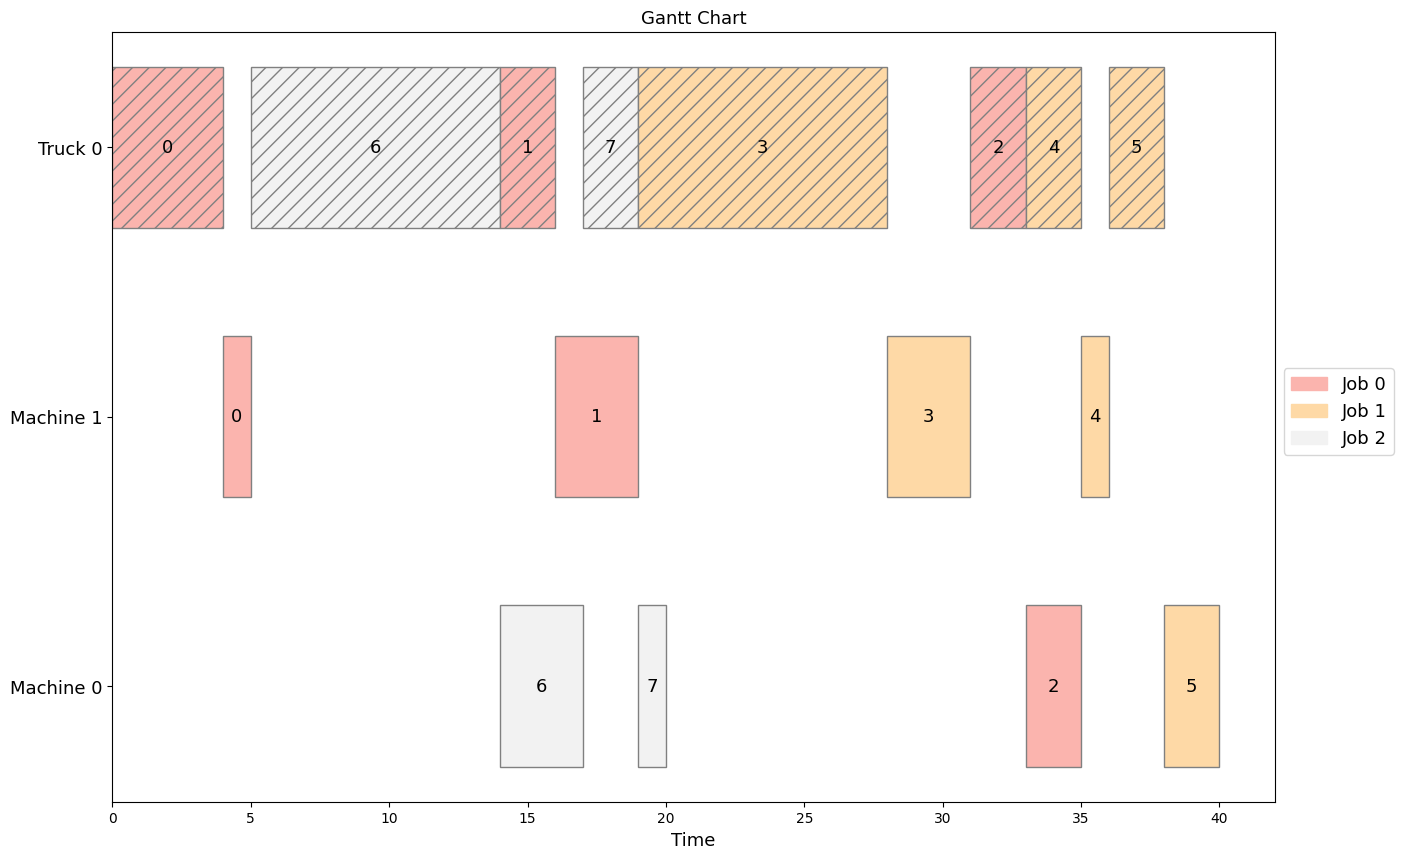

In [2]:
device = torch.device("cpu")

policy = GreedyPolicy(policy_type="FIFO")
policy = policy.to(device)

policy.eval()
td = env.reset(batch_size=[1]).to(device)
fig = None
env.render(td.cpu(), 0)
plt.show()

while not td["done"].all():
    out = policy(td)
    td["action"] = out[0].argmax(dim=1)
    td = env.step(td)["next"]
    
    clear_output(wait=True)
    if fig is not None:
        plt.close(fig)
    fig = plt.figure()
    _, machine_schedule, trucks_schedule = env.render(td.cpu(), 0)
    plt.show()
    
    time.sleep(1)